<a href="https://colab.research.google.com/github/chaudharyriya1570-sudo/end_to_end_ml/blob/main/end_to_end_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediction model 
 placement outcome based on CGPA and IQ


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/end_to_endml/Colab Notebooks/placement.csv")

In [ ]:
df.head()  

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [ ]:
df.shape  

(100, 4)

#preprocessing

In [ ]:
df.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [ ]:
df= df.iloc[:,1:]    

In [ ]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


### EDA

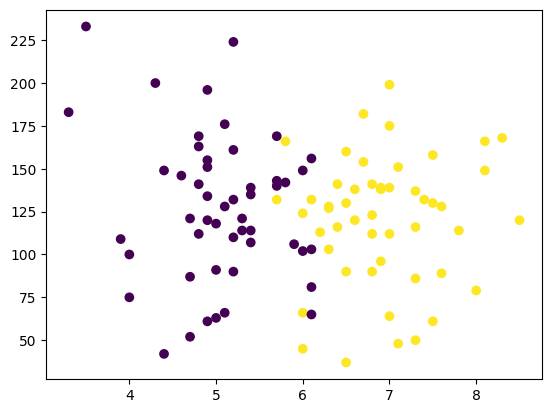

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])       

### extracting input- output columns

In [ ]:
X = df.iloc[:,:2] Y=df.iloc[:,-1] 

In [ ]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [ ]:
Y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


### Train test split

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train , Y_test = train_test_split(X,Y,test_size =0.1,random_state=42,stratify=Y )  

In [ ]:
X_train

,cgpa,iq
15,5.1,176.0
38,6.5,160.0
90,7.3,86.0
91,7.5,158.0
37,8.1,149.0
...,...,...
73,4.9,61.0
21,7.1,151.0
34,4.8,163.0
41,5.4,114.0


In [ ]:
Y_train

,placement
15,0
38,1
90,1
91,1
37,1
...,...
73,0
21,1
34,0
41,0


### scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()


In [ ]:
X_train = scaler.fit_transform(X_train)
X_train

array([[-0.76274927,  1.3473248 ],
       [ 0.43858083,  0.94860969],
       [ 1.12505517, -0.89544768],
       [ 1.29667376,  0.8987703 ],
       [ 1.81152951,  0.67449306],
       [-0.76274927, -1.39384156],
       [-1.79246078, -0.32229471],
       [-0.50532139, -0.3721341 ],
       [ 0.61019942,  0.79909153],
       [-0.67693998, -0.29737502],
       [ 1.38248305,  0.15117948],
       [ 0.52439012,  0.40037642],
       [-1.10598644, -1.74271728],
       [ 0.26696224,  0.15117948],
       [-0.24789351,  0.25085825],
       [ 0.69600871,  0.4751355 ],
       [-0.84855856, -0.09801746],
       [ 1.72572022, -1.06988554],
       [ 0.00953437,  0.0515007 ],
       [-0.93436786,  1.84571868],
       [ 0.18115295, -0.22261593],
       [ 0.781818  , -0.64625074],
       [ 0.35277154,  0.4751355 ],
       [-1.70665149, -1.16956431],
       [ 0.09534366, -1.41876125],
       [-0.16208422,  1.09812786],
       [ 2.15476669, -0.04817808],
       [-1.70665149, -0.54657196],
       [-1.10598644,

In [ ]:
X_test= scaler.transform(X_test) X_test

array([[ 0.00953437, -1.39384156],
       [-0.93436786,  0.82401122],
       [ 1.21086447,  0.25085825],
       [ 0.86762729,  1.92047776],
       [-0.93436786, -0.04817808],
       [-0.24789351,  1.17288694],
       [ 0.781818  ,  0.42529611],
       [ 0.43858083,  0.20101887],
       [-0.50532139,  0.32561734],
       [-0.50532139,  0.42529611]])

In [ ]:
print(type(X_train))
print(type(X_test))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


### Train model


In [ ]:
#using logistic regression
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

In [ ]:
clf.fit(X_train, Y_train)

In [ ]:
print(clf.get_params())

{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


### model evalution


In [ ]:
Y_pred=clf.predict(X_test)    Y_pred

array([0, 0, 1, 1, 0, 0, 1, 1, 0, 0])

In [ ]:
Y_test                   

,placement
45,1
76,0
3,1
26,1
22,0
84,0
60,1
57,1
49,0
12,0


In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test, Y_pred)

0.9

<Axes: >

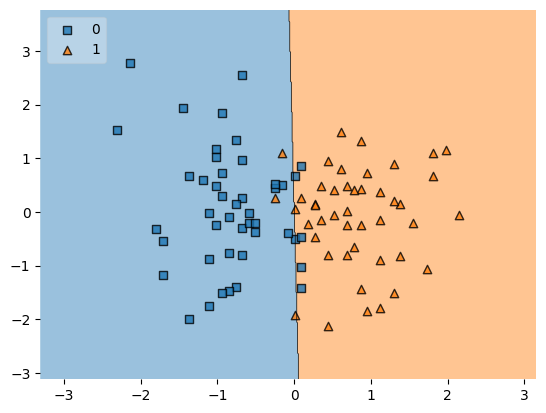

In [ ]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_train, Y_train.values, clf=clf, legend=2)

In [ ]:
import pickle
pickle.dump(clf,open('model.pkl','wb'))
